# L1.11 — Wind

**Level 1 · Core · 40 minutes**

**Goal.** You can add wind, and you know which speed each module uses.

**Check at the end.** You can say why `from_met` and `components` use opposite directions, and why
both exist.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. Two conventions, one field

`WindField` is a frozen value with two components in the east/north frame. It has two faces, and
they point **opposite** ways:

| | Direction | Who uses it |
| --- | --- | --- |
| `components()` | Where the wind **goes** (downwind). | The equations of motion. A vector sum needs a vector. |
| `coming_from()` | Where the wind **comes from**. | Every meteorological report. A 270° wind is a westerly. |

Build it either way, and read it either way:

```python
WindField(w_east=8.0, w_north=0.0)          # components, straight in
WindField.from_met(coming_from_deg=270.0, speed=8.0)   # a westerly at 8 m/s
```

`NO_WIND` is the zero field. It is the default everywhere, so every model reads unchanged without
wind.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY, GREEN, PURPLE = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c", "#9467bd"

from opencdarr import (
    M600,
    NO_WIND,
    SMALL_FIXEDWING,
    MotionCommand,
    WindField,
    create_aircraft,
    geo,
)
from opencdarr.kinematics import FixedWing, Multirotor
from opencdarr.relative import (
    air_to_ground,
    ground_speed,
    ground_to_air,
    ground_track,
    velocity_enu,
    wind_correction_angle,
)

westerly = WindField.from_met(coming_from_deg=270.0, speed=8.0)

print(f"{'':<22}{'east':>9}{'north':>9}{'speed':>9}{'coming from':>14}")
for name, w in (("NO_WIND", NO_WIND), ("westerly 8 m/s", westerly),
                ("northerly 5 m/s", WindField.from_met(0.0, 5.0)),
                ("built from parts", WindField(w_east=-3.0, w_north=4.0))):
    e, n = w.components()
    print(f"{name:<22}{e:>9.2f}{n:>9.2f}{w.speed:>9.2f}{w.coming_from:>13.1f}°")

                           east    north    speed   coming from
NO_WIND                    0.00     0.00     0.00          0.0°
westerly 8 m/s             8.00     0.00     8.00        270.0°
northerly 5 m/s           -0.00    -5.00     5.00          0.0°
built from parts          -3.00     4.00     5.00        143.1°


## 2. The wind triangle

Three vectors, and the whole of wind flying is in the sum:

$$\mathbf{V}_\text{ground} = \mathbf{V}_\text{air} + \mathbf{W}$$

- **airspeed** — what the airframe flies through the air. Its direction is the heading ψ.
- **wind** — the field.
- **ground speed** — what the ground sees. Its direction is the track χ.

Four helpers move between them:

```python
air_to_ground(v_air_enu, wind)       # add the wind
ground_to_air(v_ground_enu, wind)    # subtract it
ground_track(v_ground_enu)           # the course of a ground vector
ground_speed(v_tas, wind, psi)       # the closed form, from the cosine rule
wind_correction_angle(v_tas, wind, chi)   # the crab: psi = chi + this
```

`ground_speed` is derived independently of `air_to_ground`, so the two agreeing is a real check.

In [2]:
V_TAS, CHI = 17.0, 0.0            # fly 17 m/s airspeed, make good a course due north

crab = wind_correction_angle(V_TAS, westerly, CHI)
psi = CHI + crab

air = (V_TAS * np.sin(np.radians(psi)), V_TAS * np.cos(np.radians(psi)))
gnd = air_to_ground(air, westerly)

print(f"airspeed          {V_TAS:.2f} m/s at heading psi = {psi:.2f} deg")
print(f"crab angle        {crab:+.2f} deg")
print(f"wind              {westerly.speed:.2f} m/s from {westerly.coming_from:.0f} deg")
print(f"ground velocity   east {gnd[0]:+.3f}   north {gnd[1]:+.3f}  m/s")
print(f"ground track      {ground_track(gnd):.3f} deg   (asked for {CHI:.0f})")
print(f"ground speed      {np.hypot(*gnd):.3f} m/s")
print(f"the closed form   {ground_speed(V_TAS, westerly, psi):.3f} m/s   <- the cross-check")
print(f"\nround trip back to the air frame: {ground_to_air(gnd, westerly)}")

airspeed          17.00 m/s at heading psi = -28.07 deg
crab angle        -28.07 deg
wind              8.00 m/s from 270 deg
ground velocity   east +0.000   north +15.000  m/s
ground track      0.000 deg   (asked for 0)
ground speed      15.000 m/s
the closed form   15.000 m/s   <- the cross-check

round trip back to the air frame: (-8.0, 15.0)


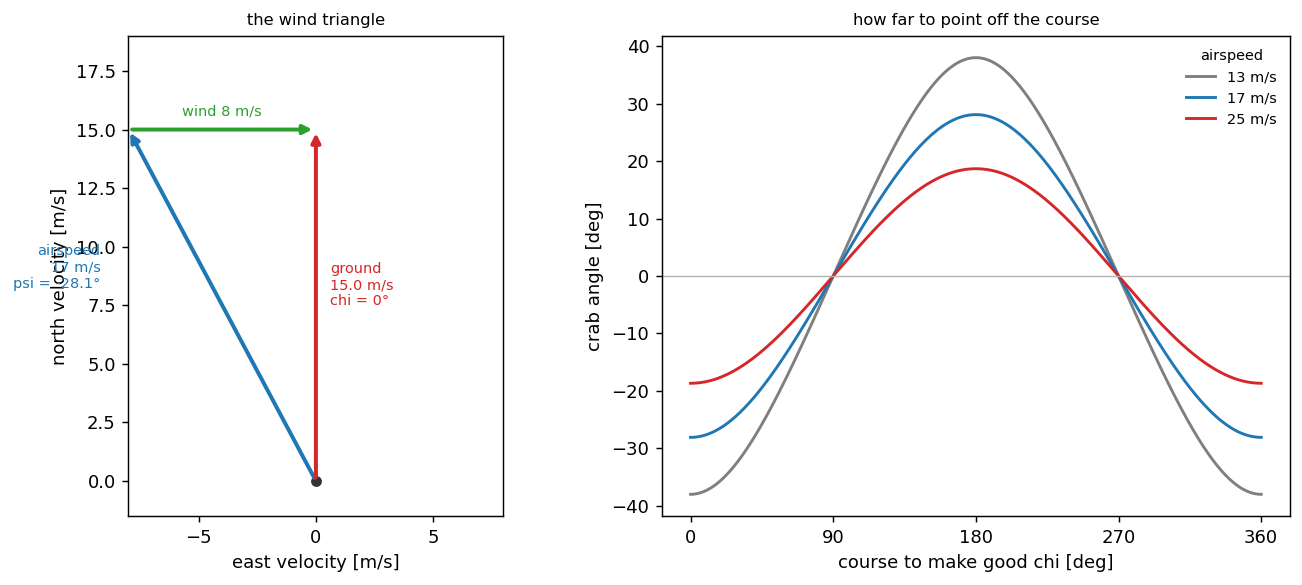

In [3]:
fig, (ax_t, ax_c) = plt.subplots(1, 2, figsize=(10.6, 4.6))

w_e, w_n = westerly.components()
ax_t.annotate("", air, (0, 0), arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2.2))
ax_t.annotate("", gnd, air, arrowprops=dict(arrowstyle="-|>", color=GREEN, lw=2.2))
ax_t.annotate("", gnd, (0, 0), arrowprops=dict(arrowstyle="-|>", color=RED, lw=2.2))
ax_t.text(air[0] - 1.2, air[1] * 0.55, f"airspeed\n{V_TAS:.0f} m/s\npsi = {psi:.1f}°",
          color=BLUE, fontsize=8, ha="right")
ax_t.text((air[0] + gnd[0]) / 2, air[1] + 0.6, f"wind {westerly.speed:.0f} m/s",
          color=GREEN, fontsize=8, ha="center")
ax_t.text(gnd[0] + 0.6, gnd[1] * 0.5, f"ground\n{np.hypot(*gnd):.1f} m/s\nchi = {CHI:.0f}°",
          color=RED, fontsize=8)
ax_t.plot(0, 0, marker="o", ms=5, color="0.2")
ax_t.set_aspect("equal")
ax_t.set_xlim(-8, 8)
ax_t.set_ylim(-1.5, 19)
ax_t.set_xlabel("east velocity [m/s]")
ax_t.set_ylabel("north velocity [m/s]")
ax_t.set_title("the wind triangle", fontsize=9)

courses = np.linspace(0.0, 360.0, 721)
for v_tas, colour in ((13.0, GREY), (17.0, BLUE), (25.0, RED)):
    crabs = [wind_correction_angle(v_tas, westerly, c) for c in courses]
    ax_c.plot(courses, [np.nan if c is None else c for c in crabs], lw=1.6, color=colour,
              label=f"{v_tas:.0f} m/s")
ax_c.axhline(0.0, lw=0.8, color="0.7")
ax_c.set_xticks([0, 90, 180, 270, 360])
ax_c.set_xlabel("course to make good chi [deg]")
ax_c.set_ylabel("crab angle [deg]")
ax_c.set_title("how far to point off the course", fontsize=9)
ax_c.legend(frameon=False, fontsize=8, title="airspeed", title_fontsize=8)
fig.tight_layout()

## 3. An unachievable course

`wind_correction_angle` returns `None` when the wind's cross-course component is larger than the
airspeed. The course cannot be flown at all. This is the fixed-wing equivalent of not enough bank.

The model does not pretend. It steers as far into the wind as it can, which is the closest
achievable course.

In [4]:
gale = WindField.from_met(coming_from_deg=270.0, speed=20.0)     # stronger than a slow airspeed

print(f"a {gale.speed:.0f} m/s wind from {gale.coming_from:.0f} deg\n")
print(f"{'airspeed':>10}{'course 000':>13}{'course 090':>13}{'course 180':>13}")
for v_tas in (12.0, 17.0, 21.0, 25.0):
    cells = []
    for chi in (0.0, 90.0, 180.0):
        crab = wind_correction_angle(v_tas, gale, chi)
        cells.append("unachievable" if crab is None else f"{crab:+.1f} deg")
    print(f"{v_tas:>10.0f}{cells[0]:>13}{cells[1]:>13}{cells[2]:>13}")

a 20 m/s wind from 270 deg

  airspeed   course 000   course 090   course 180
        12 unachievable     +0.0 deg unachievable
        17 unachievable     +0.0 deg unachievable
        21    -72.2 deg     +0.0 deg    +72.2 deg
        25    -53.1 deg     +0.0 deg    +53.1 deg


## 4. Wind reaches both airframes, through different doors

Pass `wind=` to `Kinematics.step`. Both models take it, and both use it, but they read the command
differently.

**`Multirotor`.** `target_velocity` is a **ground** velocity, and the envelope limits apply in the
**air** frame. So the model subtracts the wind, clamps the airspeed to `v_max`, and adds the wind
back. Three results follow:

- A feasible ground command is met exactly. The aircraft crabs, and `trk` differs from `yaw`.
- A command that needs more than `v_max` of airspeed clamps, and the aircraft drifts downwind.
- A **zero** ground command holds station against any wind up to `v_max` — a hover into wind.

**`FixedWing`.** `target_airspeed` is an airspeed, not a ground speed. `target_course` is a ground
course, and the model crabs to make it good. `target_airspeed_direction` commands the heading ψ
directly and overrides the course.

In [5]:
MR, FW, DT = Multirotor(), FixedWing(), 1.0
copter = create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=10.0)


def settle(command, wind, n: int = 40):
    """Hold one command until the speed ramp is finished. `ax` makes a single step misleading."""
    state = copter
    for _ in range(n):
        state = MR.step(state, command, M600, DT, wind=wind)
    return state


print("Multirotor, commanded 10 m/s of ground velocity due north, held until settled\n")
print(f"{'wind':<24}{'flown trk':>11}{'flown gs':>11}{'airspeed used':>16}")
for label, w in (("none", NO_WIND), ("8 m/s westerly", westerly),
                 ("20 m/s westerly", gale), ("30 m/s westerly", WindField.from_met(270.0, 30.0))):
    out = settle(MotionCommand.from_track_speed(0.0, 10.0), w)
    used = np.hypot(*ground_to_air(velocity_enu(out), w))
    note = "  <- clamped, so it drifts" if used > M600.v_max - 1e-6 else ""
    print(f"{label:<24}{out.trk:>11.2f}{out.gs:>11.2f}{used:>16.2f}{note}")

print(f"\ncommanded zero ground velocity (v_max is {M600.v_max:.0f} m/s):")
for label, w in (("8 m/s westerly", westerly), ("25 m/s westerly", WindField.from_met(270.0, 25.0))):
    out = settle(MotionCommand(target_velocity=(0.0, 0.0)), w)
    used = np.hypot(*ground_to_air(velocity_enu(out), w))
    verdict = "holds station" if out.gs < 1e-6 else "cannot hold, blown downwind"
    print(f"  in a {label:<18} gs {out.gs:6.3f} m/s, airspeed {used:5.2f} m/s   {verdict}")

Multirotor, commanded 10 m/s of ground velocity due north, held until settled

wind                      flown trk   flown gs   airspeed used
none                           0.00      10.00           10.00
8 m/s westerly                 0.00      10.00           12.81
20 m/s westerly               25.85       8.94           18.00  <- clamped, so it drifts
30 m/s westerly               66.23      14.12           18.00  <- clamped, so it drifts

commanded zero ground velocity (v_max is 18 m/s):
  in a 8 m/s westerly     gs  0.000 m/s, airspeed  8.00 m/s   holds station
  in a 25 m/s westerly    gs  7.000 m/s, airspeed 18.00 m/s   cannot hold, blown downwind


                                      final trk   final gs   east drift
no wind                                    0.00      17.00          0 m
8 m/s westerly                           360.00      15.00          0 m
8 m/s westerly, heading commanded         25.20      18.79        960 m


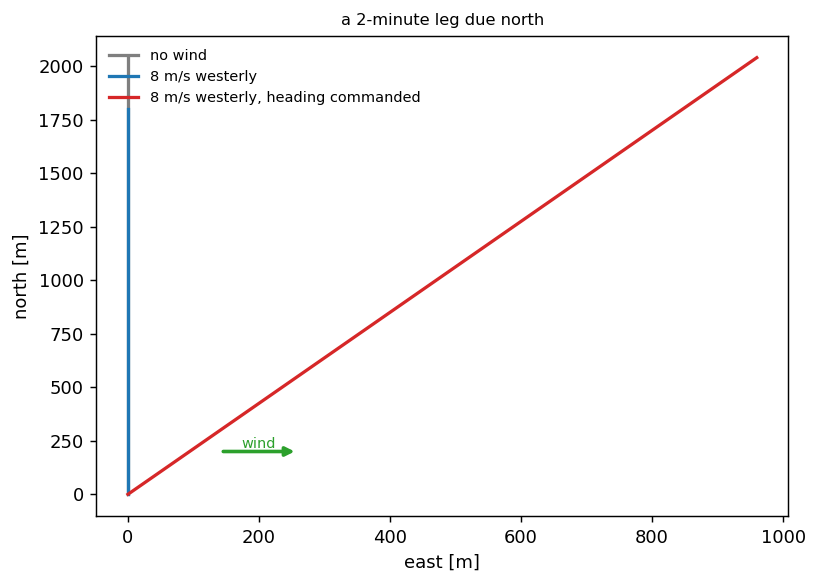

In [6]:
plane = create_aircraft(SMALL_FIXEDWING, id="PLANE", lat=52.0, lon=4.0, trk=0.0, gs=17.0)


def leg(kinematics, state, perf, command, wind, n: int):
    out = [state]
    for _ in range(n):
        out.append(kinematics.step(out[-1], command, perf, DT, wind=wind))
    return out


legs = {
    "no wind": leg(FW, plane, SMALL_FIXEDWING,
                   MotionCommand(target_course=0.0, target_airspeed=17.0), NO_WIND, 120),
    "8 m/s westerly": leg(FW, plane, SMALL_FIXEDWING,
                          MotionCommand(target_course=0.0, target_airspeed=17.0), westerly, 120),
    "8 m/s westerly, heading commanded": leg(
        FW, plane, SMALL_FIXEDWING,
        MotionCommand(target_airspeed_direction=0.0, target_airspeed=17.0), westerly, 120),
}

print(f"{'':<36}{'final trk':>11}{'final gs':>11}{'east drift':>13}")
for name, states in legs.items():
    east, _ = geo.enu(52.0, 4.0, states[-1].lat, states[-1].lon)
    print(f"{name:<36}{states[-1].trk:>11.2f}{states[-1].gs:>11.2f}{east:>11.0f} m")

fig, ax = plt.subplots(figsize=(6.4, 4.6))
for (name, states), colour in zip(legs.items(), (GREY, BLUE, RED)):
    p = np.array([geo.enu(52.0, 4.0, s.lat, s.lon) for s in states])
    ax.plot(p[:, 0], p[:, 1], lw=1.8, color=colour, label=name)
ax.annotate("", (260, 200), (140, 200), arrowprops=dict(arrowstyle="-|>", color=GREEN, lw=2.0))
ax.text(200, 215, "wind", color=GREEN, fontsize=8, ha="center")
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.set_title("a 2-minute leg due north", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

## 5. Why wind changes a conflict at all

Wind moves both aircraft, so a first guess says it cancels. It does not, for three reasons, and you
meet all three in Level 2:

1. **Different airframes crab differently.** A multirotor holds its commanded ground velocity. A
   fixed-wing at a different airspeed needs a different crab. The two tracks change by different
   amounts.
2. **A clamped command drifts.** An aircraft that cannot make its ground command loses the geometry
   its resolver assumed.
3. **The encounter takes longer or less long.** Ground speed changes, so the time to the closest
   approach changes, and every avoidance is sized in time.

In [7]:
print(f"the same 17 m/s airspeed, in the {westerly.speed:.0f} m/s westerly\n")
print(f"{'course':>8}{'crab':>9}{'ground speed':>15}{'time for 2 km':>16}")
for chi in (0.0, 90.0, 180.0, 270.0):
    crab = wind_correction_angle(17.0, westerly, chi)
    gs = ground_speed(17.0, westerly, chi + crab)
    print(f"{chi:>8.0f}{crab:>+8.1f}°{gs:>14.2f} m/s{2000.0 / gs:>14.0f} s")

the same 17 m/s airspeed, in the 8 m/s westerly

  course     crab   ground speed   time for 2 km
       0   -28.1°         15.00 m/s           133 s
      90    +0.0°         25.00 m/s            80 s
     180   +28.1°         15.00 m/s           133 s
     270    +0.0°          9.00 m/s           222 s


## Do it yourself

1. Build the same wind with `WindField(w_east=..., w_north=...)` and with `from_met`. Check that
   `components()` agrees.
2. Command a multirotor to hold station in a 25 m/s wind. Its `v_max` is 18 m/s. Read what happens.
3. Fly the fixed-wing leg of section 4 due **east** and due **west**. Compare the two flight times.
4. Find the airspeed at which a course of 000 becomes unachievable in the 20 m/s wind.

## Check

1. Why do `from_met` and `components` point opposite ways, and why do both exist?
2. A multirotor is commanded a ground velocity, and its envelope limits an airspeed. What does the
   model do between the two?
3. Wind moves both aircraft. Give one reason it still changes the separation between them.

## Next

`L1.12 — CNS: navigation`. The environment is complete. Next the aircraft start to be wrong about
where they are.